In [80]:
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt


In [81]:
# Base Data Model Implementation

# BaseDataModel class represents the basic structure for data models, with common attributes and methods.
class BaseDataModel:
    def __init__(self, timestamp, symbol=None):
        # Initialize with timestamp and optional symbol
        self.timestamp = timestamp if isinstance(timestamp, datetime) else datetime.now()
        self.symbol = symbol  # Optional, for models where a symbol might be applicable

    def __repr__(self):
        # String representation of the base data model
        return f"BaseDataModel(Timestamp: {self.timestamp}, Symbol: {self.symbol})"

    def is_recent(self, days=7):
        """
        Checks if the data point is within a recent range (e.g., last 7 days).
        :param days: Number of days to define 'recent'.
        :return: Boolean indicating if the timestamp is within the specified range.
        """
        delta = datetime.now() - self.timestamp
        return delta.days <= days

    def is_above_threshold(self, value, threshold):
        """
        Checks if a given value is above a threshold.
        :param value: The data point value to check.
        :param threshold: The threshold to compare against.
        :return: Boolean indicating if the value is above the threshold.
        """
        return value > threshold


# Derived Data Models Using BaseDataModel

# IntradayDataModel class inherits from BaseDataModel and represents intraday trading data.
class IntradayDataModel(BaseDataModel):
    def __init__(self, timestamp, price, volume, symbol):
        super().__init__(timestamp, symbol)
        self.price = price  # Price of the asset
        self.volume = volume  # Volume of trades

    def __repr__(self):
        # String representation of the intraday data model
        return f"IntradayDataModel({self.symbol}, {self.timestamp}, Price: {self.price}, Volume: {self.volume})"

    def aggregate_by_interval(self, interval, data):
        """
        Aggregates data by the given interval.
        :param interval: The interval for aggregation.
        :param data: List of IntradayDataModel objects.
        :return: List of aggregated IntradayDataModel objects.
        """
        aggregated_data = []
        # Placeholder aggregation logic: e.g., summing volumes over the given interval
        for i in range(0, len(data), interval):
            interval_data = data[i:i+interval]
            price_avg = sum([item.price for item in interval_data]) / len(interval_data)
            volume_sum = sum([item.volume for item in interval_data])
            aggregated_data.append(IntradayDataModel(interval_data[-1].timestamp, price_avg, volume_sum, self.symbol))
        return aggregated_data


# NewsDataModel class inherits from BaseDataModel and represents news data related to financial markets.
class NewsDataModel(BaseDataModel):
    def __init__(self, timestamp, headline, sentiment_score, relevance, source):
        super().__init__(timestamp)
        self.headline = headline  # News headline
        self.sentiment_score = sentiment_score  # Sentiment score of the news
        self.relevance = relevance  # Relevance score of the news
        self.source = source  # Source of the news

    def __repr__(self):
        # String representation of the news data model
        return f"NewsDataModel(Timestamp: {self.timestamp}, Headline: {self.headline[:30]}, Sentiment: {self.sentiment_score})"

    def filter_by_sentiment(self, threshold):
        """
        Filters news based on sentiment score.
        :param threshold: Sentiment threshold to filter by.
        :return: Boolean indicating if sentiment is above the threshold.
        """
        return self.is_above_threshold(self.sentiment_score, threshold)

    def group_by_sentiment(self, data):
        """
        Groups news data by sentiment (positive or negative).
        :param data: List of NewsDataModel objects.
        :return: Dictionary with positive and negative news lists.
        """
        positive = [news for news in data if news.sentiment_score > 0]
        negative = [news for news in data if news.sentiment_score < 0]
        return {'positive': positive, 'negative': negative}


# CompanyFinancialsDataModel class inherits from BaseDataModel and represents financial data for a company.
class CompanyFinancialsDataModel(BaseDataModel):
    def __init__(self, symbol, period, revenue, profit, analyst_recommendation):
        super().__init__(None, symbol)  # No timestamp for company financials
        self.period = period  # Financial period (e.g., Q1 2024)
        self.revenue = revenue  # Revenue of the company
        self.profit = profit  # Profit of the company
        self.analyst_recommendation = analyst_recommendation  # Analyst recommendation score

    def __repr__(self):
        # String representation of the company financials data model
        return f"CompanyFinancialsDataModel(Symbol: {self.symbol}, Period: {self.period}, Revenue: {self.revenue})"

    def calculate_profit_margin(self):
        """
        Calculates the profit margin of the company.
        :return: Profit margin as a percentage.
        """
        return (self.profit / self.revenue) * 100 if self.revenue > 0 else None


# EconomicIndicatorDataModel class inherits from BaseDataModel and represents economic indicator data.
class EconomicIndicatorDataModel(BaseDataModel):
    def __init__(self, country, indicator_name, date, value, unit):
        super().__init__(date)  # Use date as the timestamp for economic data
        self.country = country  # Country of the economic indicator
        self.indicator_name = indicator_name  # Name of the economic indicator
        self.value = value  # Value of the economic indicator
        self.unit = unit  # Unit of measurement (e.g., percent)

    def __repr__(self):
        # String representation of the economic indicator data model
        return f"EconomicIndicatorDataModel({self.country}, {self.indicator_name}, Value: {self.value} {self.unit})"

    def is_above_threshold(self, threshold):
        """
        Checks if the economic indicator value is above a given threshold.
        :param threshold: Threshold to compare against.
        :return: Boolean indicating if the value is above the threshold.
        """
        return super().is_above_threshold(self.value, threshold)

In [82]:
# Data Lake Implementation

# The DataLake class manages the storage of raw and processed data, with role-based access.
class DataLake:
    def __init__(self):
        self.raw_data = {}
        self.processed_data = {}
        self.user_roles = {}

    def store_data(self, dataset_name, data, processed=False):
        """
        Stores data in the data lake, either as raw or processed.
        :param dataset_name: Name of the dataset to store.
        :param data: The data to be stored.
        :param processed: Boolean flag indicating if the data is processed.
        """
        if processed:
            self.processed_data[dataset_name] = data
        else:
            self.raw_data[dataset_name] = data

    def retrieve_data(self, dataset_name, processed=False):
        """
        Retrieves data from the data lake.
        :param dataset_name: Name of the dataset to retrieve.
        :param processed: Boolean flag indicating if the data is processed.
        :return: The requested data, or None if not found.
        """
        return self.processed_data.get(dataset_name) if processed else self.raw_data.get(dataset_name)

    def set_user_role(self, user, role):
        """
        Assigns a role to a user for data access.
        :param user: The user to assign the role to.
        :param role: The role to assign (e.g., 'admin', 'guest').
        """
        self.user_roles[user] = role

    def get_user_role(self, user):
        """
        Retrieves the role assigned to a user.
        :param user: The user whose role is being requested.
        :return: The role of the user, or 'guest' if no role is found.
        """
        return self.user_roles.get(user, "guest")

    def query_data(self, dataset_name, query_conditions, processed=False):
        """
        Queries data from the data lake based on specific conditions (schema-on-read).
        :param dataset_name: Name of the dataset to query.
        :param query_conditions: Conditions to filter the data.
        :param processed: Boolean flag indicating if the data is processed.
        :return: Filtered data based on the query conditions.
        """
        # Placeholder: Iterate over data and apply conditions dynamically
        data = self.retrieve_data(dataset_name, processed)
        # Apply query_conditions here...
        # return [item for item in data if all(condition(item) for condition in query_conditions)]
        return data


In [83]:
# Example Usage
lake = DataLake()
lake.store_data('AAPL_intraday_prices', [
    {'timestamp': '2024-11-17 09:30:00', 'price': 150, 'volume': 1000},
    {'timestamp': '2024-11-17 09:45:00', 'price': 152, 'volume': 1200},
    {'timestamp': '2024-11-17 10:00:00', 'price': 165, 'volume': 1800},  # Positive earnings news impact
    {'timestamp': '2024-11-17 10:15:00', 'price': 170, 'volume': 1700},
    {'timestamp': '2024-11-17 10:30:00', 'price': 175, 'volume': 2000},
    {'timestamp': '2024-11-17 10:45:00', 'price': 178, 'volume': 2100},
    {'timestamp': '2024-11-17 11:00:00', 'price': 180, 'volume': 2200},
    {'timestamp': '2024-11-17 11:15:00', 'price': 185, 'volume': 2300},
    {'timestamp': '2024-11-17 11:30:00', 'price': 190, 'volume': 2400},
    {'timestamp': '2024-11-17 11:45:00', 'price': 195, 'volume': 2500}
], processed=False)

lake.store_data('MSFT_intraday_prices', [
    {'timestamp': '2024-11-17 09:30:00', 'price': 145, 'volume': 2000},
    {'timestamp': '2024-11-17 09:45:00', 'price': 148, 'volume': 1800},
    {'timestamp': '2024-11-17 10:00:00', 'price': 150, 'volume': 1600},
    {'timestamp': '2024-11-17 10:15:00', 'price': 160, 'volume': 1700},
    {'timestamp': '2024-11-17 10:30:00', 'price': 165, 'volume': 2000},  # Product launch news impact
    {'timestamp': '2024-11-17 10:45:00', 'price': 170, 'volume': 2100},
    {'timestamp': '2024-11-17 11:00:00', 'price': 175, 'volume': 2200},
    {'timestamp': '2024-11-17 11:15:00', 'price': 180, 'volume': 2300},
    {'timestamp': '2024-11-17 11:30:00', 'price': 182, 'volume': 2400},
    {'timestamp': '2024-11-17 11:45:00', 'price': 185, 'volume': 2500}
], processed=False)

data = lake.retrieve_data('AAPL_intraday_prices')
print(data)


[{'timestamp': '2024-11-17 09:30:00', 'price': 150, 'volume': 1000}, {'timestamp': '2024-11-17 09:45:00', 'price': 152, 'volume': 1200}, {'timestamp': '2024-11-17 10:00:00', 'price': 165, 'volume': 1800}, {'timestamp': '2024-11-17 10:15:00', 'price': 170, 'volume': 1700}, {'timestamp': '2024-11-17 10:30:00', 'price': 175, 'volume': 2000}, {'timestamp': '2024-11-17 10:45:00', 'price': 178, 'volume': 2100}, {'timestamp': '2024-11-17 11:00:00', 'price': 180, 'volume': 2200}, {'timestamp': '2024-11-17 11:15:00', 'price': 185, 'volume': 2300}, {'timestamp': '2024-11-17 11:30:00', 'price': 190, 'volume': 2400}, {'timestamp': '2024-11-17 11:45:00', 'price': 195, 'volume': 2500}]


In [84]:
# Data Catalog Implementation

class DataCategory:
    def __init__(self, name):
        """
        Initializes a new data category.
        :param name: The name of the data category.
        """
        self.name = name
        self.datasets = []

    def add_dataset(self, dataset):
        """
        Adds a dataset to the category.
        :param dataset: The dataset to add.
        """
        self.datasets.append(dataset)

    def search(self, keyword):
        """
        Searches for datasets in the category based on a keyword.
        :param keyword: The keyword to search for.
        :return: List of datasets matching the keyword.
        """
        return [dataset for dataset in self.datasets if keyword.lower() in dataset.name.lower()]

class DataCatalog:
    def __init__(self):
        """
        Initializes the data catalog.
        """
        self.categories = {}

    def add_category(self, name):
        """
        Adds a new category to the catalog.
        :param name: The name of the category to add.
        """
        if name not in self.categories:
            self.categories[name] = DataCategory(name)

    def add_dataset(self, category_name, dataset):
        """
        Adds a dataset to a specific category.
        :param category_name: The category to which the dataset should be added.
        :param dataset: The dataset to add.
        """
        if category_name in self.categories:
            self.categories[category_name].add_dataset(dataset)
        else:
            print(f"Category '{category_name}' not found.")

    def list_datasets(self, category_name):
        """
        Lists all datasets in a specific category.
        :param category_name: The name of the category to list datasets from.
        :return: List of dataset names in the category, or an error message if the category is not found.
        """
        if category_name in self.categories:
            return [dataset.name for dataset in self.categories[category_name].datasets]
        return "Category not found."

    def search_data(self, keyword):
        """
        Searches for datasets across all categories based on a keyword.
        :param keyword: The keyword to search for.
        :return: List of datasets matching the keyword.
        """
        results = []
        for category in self.categories.values():
            results.extend(category.search(keyword))
        return results
    
    def get_metadata(self, dataset_name):
        """
        Retrieves metadata for a specific dataset.
        :param dataset_name: The name of the dataset to get metadata for.
        :return: A dictionary containing metadata for the dataset.
        """
        # Fetch detailed metadata for a dataset, placeholder implementation
        return {
            "name": dataset_name,
            "source": "Sample Source",
            "update_frequency": "Daily",
            "description": "A sample dataset"
        }

In [85]:
# Example Usage
catalog = DataCatalog()
catalog.add_category('Equities')
catalog.add_dataset('Equities', DataCategory('AAPL Intraday Data'))
print(catalog.list_datasets('Equities'))


['AAPL Intraday Data']


In [86]:
# Data Workbench Implementation

class DataWorkbench:
    def __init__(self):
        """
        Initializes the data workbench for data storage and transformation.
        """
        self.data_storage = {}

    def store_data(self, dataset_name, data):
        """
        Stores data in the workbench for further transformation.
        :param dataset_name: The name of the dataset to store.
        :param data: The data to be stored.
        """
        self.data_storage[dataset_name] = data

    def retrieve_data(self, dataset_name):
        """
        Retrieves stored data from the workbench.
        :param dataset_name: The name of the dataset to retrieve.
        :return: The requested data, or an error message if not found.
        """
        return self.data_storage.get(dataset_name, "Dataset not found")

    def transform_data(self, dataset_name, transformation_func):
        """
        Transforms data using a specified transformation function.
        :param dataset_name: The name of the dataset to transform.
        :param transformation_func: A function that performs the transformation.
        :return: Transformed data, or an error message if the dataset is not found.
        """
        data = self.retrieve_data(dataset_name)
        return transformation_func(data) if data else "Dataset not found"

    def resample_data(self, dataset_name, frequency):
        """
        Resamples data at a specified frequency.
        :param dataset_name: The name of the dataset to resample.
        :param frequency: The frequency at which to resample the data.
        :return: Resampled data, or None if the data is not a DataFrame.
        """
        data = self.retrieve_data(dataset_name)
        # Resampling logic based on the frequency provided
        # Placeholder: Example using Pandas to resample a DataFrame
        return data.resample(frequency).mean() if isinstance(data, pd.DataFrame) else None

    def detect_missing_values(self, dataset_name):
        """
        Detects missing values in a dataset.
        :param dataset_name: The name of the dataset to check for missing values.
        :return: A summary of missing values, or a message if the data is not a DataFrame.
        """
        data = self.retrieve_data(dataset_name)
        if isinstance(data, pd.DataFrame):
            return data.isnull().sum()
        return "No missing values found"


In [87]:
# Example Usage
def clean_data(data):
    # Transformation logic here
    return data


In [88]:
workbench = DataWorkbench()
workbench.store_data('intraday_prices', {'timestamp': '2024-11-17', 'price': 150})
transformed_data = workbench.transform_data('intraday_prices', clean_data)
print(transformed_data)


{'timestamp': '2024-11-17', 'price': 150}


In [89]:
# Event Study Implementation in Jupyter Notebook

# Data Retrieval from the Data Lake
# Convert the data for multiple stocks into pandas DataFrames
df_aapl_intraday = pd.DataFrame(lake.retrieve_data('AAPL_intraday_prices'))
df_msft_intraday = pd.DataFrame(lake.retrieve_data('MSFT_intraday_prices'))

# Adding some more stock data for a more comprehensive event study
lake.store_data('GOOG_intraday_prices', [
    {'timestamp': '2024-11-17 09:30:00', 'price': 155, 'volume': 1300},
    {'timestamp': '2024-11-17 09:45:00', 'price': 157, 'volume': 1400},
    {'timestamp': '2024-11-17 10:00:00', 'price': 155, 'volume': 1500},  # Slight drop before news
    {'timestamp': '2024-11-17 10:15:00', 'price': 150, 'volume': 1600},
    {'timestamp': '2024-11-17 10:30:00', 'price': 145, 'volume': 1700},
    {'timestamp': '2024-11-17 10:45:00', 'price': 140, 'volume': 1800},  # Negative regulatory news impact
    {'timestamp': '2024-11-17 11:00:00', 'price': 135, 'volume': 1900},
    {'timestamp': '2024-11-17 11:15:00', 'price': 130, 'volume': 2000},
    {'timestamp': '2024-11-17 11:30:00', 'price': 128, 'volume': 2100},
    {'timestamp': '2024-11-17 11:45:00', 'price': 125, 'volume': 2200}
], processed=False)

df_goog_intraday = pd.DataFrame(lake.retrieve_data('GOOG_intraday_prices'))
df_goog_intraday


,timestamp,price,volume
0,2024-11-17 09:30:00,155,1300
1,2024-11-17 09:45:00,157,1400
2,2024-11-17 10:00:00,155,1500
3,2024-11-17 10:15:00,150,1600
4,2024-11-17 10:30:00,145,1700
5,2024-11-17 10:45:00,140,1800
6,2024-11-17 11:00:00,135,1900
7,2024-11-17 11:15:00,130,2000
8,2024-11-17 11:30:00,128,2100
9,2024-11-17 11:45:00,125,2200


In [90]:
# News Data Retrieval
news_data = [
    {
        'timestamp': '2024-11-17 10:00:00',
        'headline': 'Positive Earnings Report for AAPL',
        'sentiment_score': 0.9,
        'relevance': 0.95
    },
    {
        'timestamp': '2024-11-17 10:30:00',
        'headline': 'MSFT Announces New Product Line',
        'sentiment_score': 0.8,
        'relevance': 0.9
    },
    {
        'timestamp': '2024-11-17 10:45:00',
        'headline': 'GOOG Faces Regulatory Scrutiny',
        'sentiment_score': -0.7,
        'relevance': 0.85
    }
]
df_news = pd.DataFrame(news_data)
df_news


,timestamp,headline,sentiment_score,relevance
0,2024-11-17 10:00:00,Positive Earnings Report for AAPL,0.9,0.95
1,2024-11-17 10:30:00,MSFT Announces New Product Line,0.8,0.90
2,2024-11-17 10:45:00,GOOG Faces Regulatory Scrutiny,-0.7,0.85


In [91]:
# Display retrieved data to confirm
print("AAPL Intraday Data:\n", df_aapl_intraday)
print("MSFT Intraday Data:\n", df_msft_intraday)
print("GOOG Intraday Data:\n", df_goog_intraday)
print("News Data:\n", df_news)


AAPL Intraday Data:
              timestamp  price  volume
0  2024-11-17 09:30:00    150    1000
1  2024-11-17 09:45:00    152    1200
2  2024-11-17 10:00:00    165    1800
3  2024-11-17 10:15:00    170    1700
4  2024-11-17 10:30:00    175    2000
5  2024-11-17 10:45:00    178    2100
6  2024-11-17 11:00:00    180    2200
7  2024-11-17 11:15:00    185    2300
8  2024-11-17 11:30:00    190    2400
9  2024-11-17 11:45:00    195    2500
MSFT Intraday Data:
              timestamp  price  volume
0  2024-11-17 09:30:00    145    2000
1  2024-11-17 09:45:00    148    1800
2  2024-11-17 10:00:00    150    1600
3  2024-11-17 10:15:00    160    1700
4  2024-11-17 10:30:00    165    2000
5  2024-11-17 10:45:00    170    2100
6  2024-11-17 11:00:00    175    2200
7  2024-11-17 11:15:00    180    2300
8  2024-11-17 11:30:00    182    2400
9  2024-11-17 11:45:00    185    2500
GOOG Intraday Data:
              timestamp  price  volume
0  2024-11-17 09:30:00    155    1300
1  2024-11-17 09:45:00   

In [92]:
# Step 2: Data Transformation using Data Workbench
# Aggregating intraday data to 30-minute intervals
workbench = DataWorkbench()
workbench.store_data('AAPL_intraday_prices', df_aapl_intraday)
workbench.store_data('MSFT_intraday_prices', df_msft_intraday)
workbench.store_data('GOOG_intraday_prices', df_goog_intraday)

# Using resample_data to resample data to a 30-minute interval (assuming datetime index)
def prepare_dataframe(df):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)
    return df

# Prepare and resample the data for AAPL, MSFT, and GOOG
df_aapl_prepared = prepare_dataframe(df_aapl_intraday)
df_msft_prepared = prepare_dataframe(df_msft_intraday)
df_goog_prepared = prepare_dataframe(df_goog_intraday)

# Store prepared data back in the workbench
workbench.store_data('AAPL_intraday_prices_prepared', df_aapl_prepared)
workbench.store_data('MSFT_intraday_prices_prepared', df_msft_prepared)
workbench.store_data('GOOG_intraday_prices_prepared', df_goog_prepared)

# Resampling data to 30-minute intervals
aapl_resampled = workbench.resample_data('AAPL_intraday_prices_prepared', '30T')
msft_resampled = workbench.resample_data('MSFT_intraday_prices_prepared', '30T')
goog_resampled = workbench.resample_data('GOOG_intraday_prices_prepared', '30T')

# Display resampled data
print("\nAAPL Resampled Data:\n", aapl_resampled)
print("\nMSFT Resampled Data:\n", msft_resampled)
print("\nGOOG Resampled Data:\n", goog_resampled)



AAPL Resampled Data:
                      price  volume
timestamp                         
2024-11-17 09:30:00  151.0  1100.0
2024-11-17 10:00:00  167.5  1750.0
2024-11-17 10:30:00  176.5  2050.0
2024-11-17 11:00:00  182.5  2250.0
2024-11-17 11:30:00  192.5  2450.0

MSFT Resampled Data:
                      price  volume
timestamp                         
2024-11-17 09:30:00  146.5  1900.0
2024-11-17 10:00:00  155.0  1650.0
2024-11-17 10:30:00  167.5  2050.0
2024-11-17 11:00:00  177.5  2250.0
2024-11-17 11:30:00  183.5  2450.0

GOOG Resampled Data:
                      price  volume
timestamp                         
2024-11-17 09:30:00  156.0  1350.0
2024-11-17 10:00:00  152.5  1550.0
2024-11-17 10:30:00  142.5  1750.0
2024-11-17 11:00:00  132.5  1950.0
2024-11-17 11:30:00  126.5  2150.0


/var/folders/hl/vvvhphdj52dbn49dls4zs5fh0000gn/T/ipykernel_35402/649735662.py:46: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  return data.resample(frequency).mean() if isinstance(data, pd.DataFrame) else None


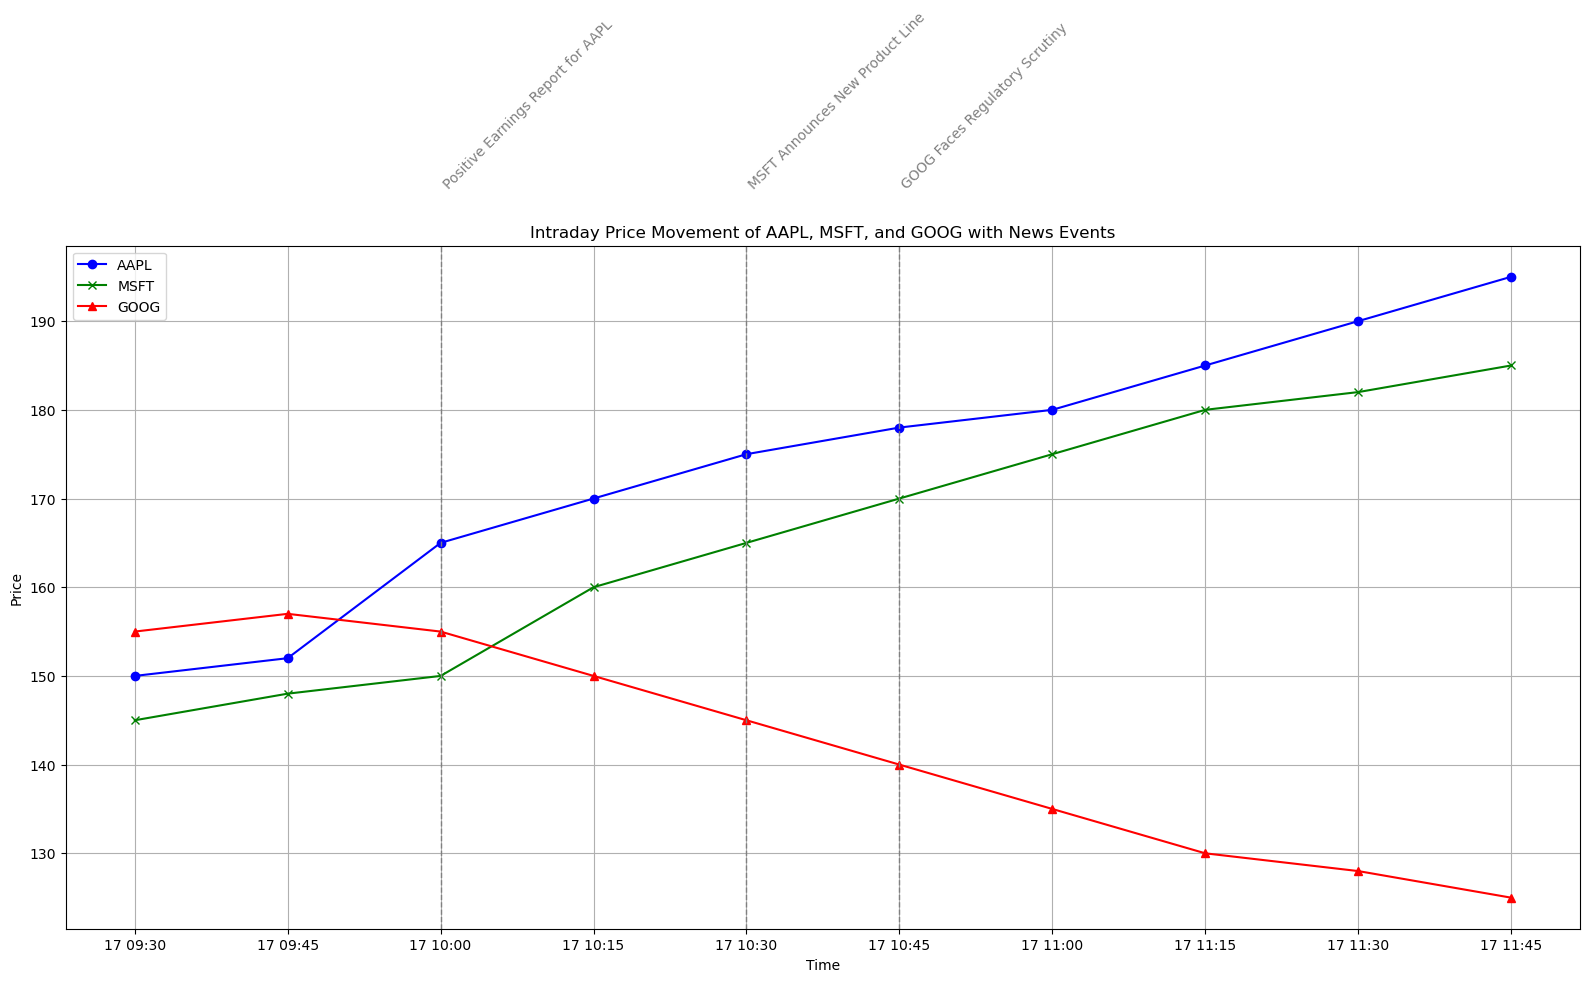

In [93]:
# Step 3: Data Analysis
# Visualizing the price movement of AAPL, MSFT, and GOOG alongside news events
plt.figure(figsize=(16, 10))

# Plotting resampled intraday price data for each stock
plt.plot(df_aapl_prepared.index, df_aapl_prepared['price'], label='AAPL', linestyle='-', marker='o', color='blue')
plt.plot(df_msft_prepared.index, df_msft_prepared['price'], label='MSFT', linestyle='-', marker='x', color='green')
plt.plot(df_goog_prepared.index, df_goog_prepared['price'], label='GOOG', linestyle='-', marker='^', color='red')

# Highlighting news events on the plot
for _, row in df_news.iterrows():
    plt.axvline(pd.to_datetime(row['timestamp']), color='gray', linestyle='--', linewidth=1)
    plt.text(pd.to_datetime(row['timestamp']), max(df_aapl_prepared['price'].max(), df_msft_prepared['price'].max(), df_goog_prepared['price'].max()) + 10, 
             row['headline'], rotation=45, color='gray')

plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Intraday Price Movement of AAPL, MSFT, and GOOG with News Events')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Saving the plot for visualization
plt.savefig("enhanced_event_study_plot_updated.png")
plt.show()
